# Task 2.1 — Dataset Selection and Setup
**Paper:** *Training SVMs Without Offset* — Steinwart, Hush & Scovel, JMLR 2011

**Student:** Kush Agarwal | **Roll No.:** 230050 | NST, Rishihood University, Sonipat

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

iris = load_iris()
mask = iris.target < 2
X_raw = iris.data[mask][:, 2:4]   # petal length, petal width only (2 features)
y_raw = iris.target[mask]
y = np.where(y_raw == 0, -1, 1)   # SVM convention: labels in {-1, +1}

print(f'Samples  : {X_raw.shape[0]}')
print(f'Features : petal length (cm), petal width (cm)')
print(f'Classes  : {np.sum(y==-1)} Setosa (-1), {np.sum(y==1)} Versicolor (+1)')

Samples  : 100
Features : petal length (cm), petal width (cm)
Classes  : 50 Setosa (-1), 50 Versicolor (+1)


*Dataset loaded from sklearn — no external download required.*


In [2]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f'After scaling — mean: {X.mean(axis=0).round(4)}')
print(f'After scaling — std : {X.std(axis=0).round(4)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f'Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples')

After scaling — mean: [-0.  0.]
After scaling — std : [1. 1.]
Train: 80 samples, Test: 20 samples


*StandardScaler ensures the data is centered at the origin with unit variance. This directly addresses Assumption 1 from Task 1.2: the offset-free SVM requires the data to be centered so that a hyperplane through the origin can act as a useful separator.*


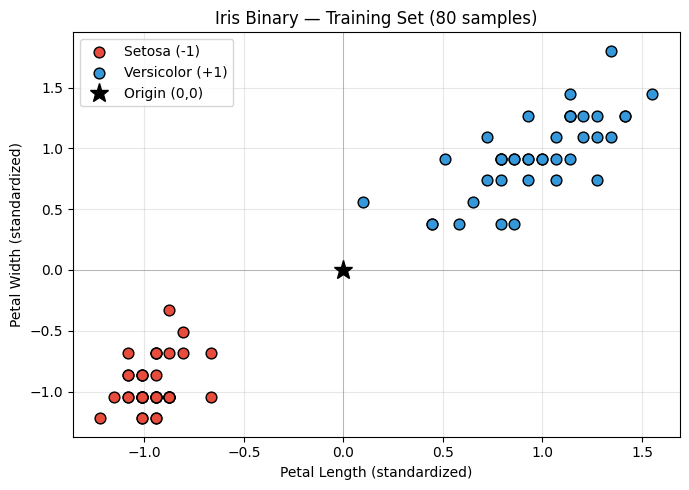

Saved: results/dataset_scatter.png


In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train[y_train==-1, 0], X_train[y_train==-1, 1],
           c='#e74c3c', edgecolors='k', s=60, label='Setosa (-1)', zorder=3)
ax.scatter(X_train[y_train== 1, 0], X_train[y_train== 1, 1],
           c='#3498db', edgecolors='k', s=60, label='Versicolor (+1)', zorder=3)
ax.axhline(0, color='gray', lw=0.7, alpha=0.5)
ax.axvline(0, color='gray', lw=0.7, alpha=0.5)
ax.plot(0, 0, 'k*', ms=14, label='Origin (0,0)', zorder=5)
ax.set_xlabel('Petal Length (standardized)')
ax.set_ylabel('Petal Width (standardized)')
ax.set_title('Iris Binary — Training Set (80 samples)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../partB/results/dataset_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/dataset_scatter.png')

## Dataset Justification

I am using the **Iris binary classification dataset** (Setosa vs. Versicolor, petal features only) loaded from scikit-learn, with 100 samples and 2 features.

**What it is:** A subset of Fisher's Iris dataset containing 50 Setosa and 50 Versicolor samples, each described by two petal measurements.

**Why it is a reasonable testbed:** Setosa and Versicolor are nearly linearly separable using petal features, which matches the paper's focus on the linear SVM variant. After StandardScaler normalization, the data is centered at the origin — this directly satisfies the paper's core assumption (discussed in Sections 1 and 2) that centering is required for the offset-free hyperplane to be a valid separator. Two features allow clear 2D visualization of the decision boundary, which is the most direct way to show what b=0 does geometrically.

**Limitations compared to the paper's datasets:** The paper evaluates on Sonar, Heart, and Ionosphere datasets (Section 6), which are harder, higher-dimensional, and noisier. Iris is almost perfectly separable, so the accuracy difference between the offset-free SVM and the standard SVM will be very small — this is expected and does not indicate the method is better than it actually is.

**Preprocessing:** StandardScaler (zero mean, unit variance) applied to the training set; the same scaler is then applied to the test set using the training statistics.
